# Лобораторна робота №1

Ми з вами обробляємо данні продажів у інтернет магазині. Керівництво магазину вирішило деякі товари продавати по спеціальній пропозиції (с.п.)  
Умови цієї пропозиції:
- доставка замовлень з товарами по с.п. безкоштовно
- вартість доставки всіх інших замовлень - 20грн
- якщо товар по с.п. не підійшов то його можна повернути бкзкоштовно (і лише його!)

Данні. Кожний рядок у файлі - одне замовлення для клієнта магазину:
- total: сумарна віртість замовлення  
- return: чи повернуто товар по с.п.  (True = повернуто)
- special_proposition: вартість товару зі с.п.  

Керівництво магазину зрозуміло, що деякі замовники використовують с.п. задля безкоштовного доставлення інших товарів. Нам дана задача побудувати аналітику та орієнтовно оцінити об'єми недоброчесних дій деяких замовників

In [2]:
import pandas as pd
data = pd.read_csv("data.csv")
data.head(4)

,Unnamed: 0,total,return,special_proposition
0,0,88.678970,False,9.141027
1,1,104.085105,True,8.569498
2,2,136.883561,False,50.300859
3,3,122.467426,False,44.532713


# Позначення
$1\leq i \leq n$  
$\xi_i + \eta_i$ - сумарна вартість замовлення (total)  
$\eta_i$ - вартість товару із с.п. (special_proposition)  
$\xi_i$ - вартість інших товарів (без с.п.) (?)  

$p_i$ - чи був товар із с.п. повернуто (return)


# 1. Об'єми повернень
В даній частині роботи нас цікавить ймовірніть того, що користувач поверне товар

### Задачі:
1. Оцініть ймовірніть повернення товару із с.п. $p$
2. Побудуйте для цієї ймовірності $p$ довірчі інтервали із рівнями 95% та 99%

(Підказка: випробування Бернулі)

In [8]:

import numpy as np
from scipy import stats

# 1. Визначаємо загальну кількість замовлень n
n = len(data)

# 2. Розрахунок кількості повернень та оцінки ймовірності
r = int(data['return'].sum())
p_hat = r / n

print(f'Кількість повернень = {r}')
print(f'Оцінка ймовірності повернення p̂ = {p_hat:.6f}')

# 3. Побудова довірчих інтервалів
for confidence in [0.95, 0.99]:
    alpha = 1 - confidence
    z = stats.norm.ppf(1 - alpha / 2)
    se = np.sqrt(p_hat * (1 - p_hat) / n)
    left = max(0, p_hat - z * se)
    right = min(1, p_hat + z * se)
    print(f'{int(confidence * 100)}% ДІ: ({left:.6f}; {right:.6f})')

Кількість повернень = 278
Оцінка ймовірності повернення p̂ = 0.278000
95% ДІ: (0.250232; 0.305768)
99% ДІ: (0.241507; 0.314493)


# 2. Вартість товарів по с.п.
В даній секції нас цікавить аналітика цін товарів по с.п.

### Задачі:
1. Оцініть середню вартість товару із с.п. $\mu$
2. Побудуйте для середньої вартості товару із с.п. $\mu$ довірчі інтервали із рівнями 95% та 99%

### Задачі:
Припустимо, що вартість товарів по с.п. ($\eta_i$) має розподіл $Exp(\lambda k)$, k>0, $\lambda$>0  
1. Побудуйте гістограму та еміричну функцію розподілу для ціни товарів по с.п.
2. Оцініть параметр $\lambda k$ розподілу
3. Побудуйте теоретичну функцію розподілу, в який підставите оцінку $\lambda k$

(Підказка: $\lambda k$ - один параметр, який треба оцінити)

Середня вартість товару по с.п. μ̂ = 31.323301
Вибіркове стандартне відхилення s = 31.647572
95% ДІ: (29.359421; 33.287181)
99% ДІ: (28.740518; 33.906085)
Оцінка параметра λk = 0.031925


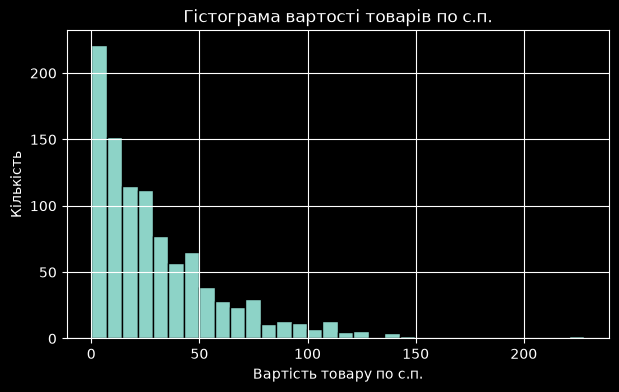

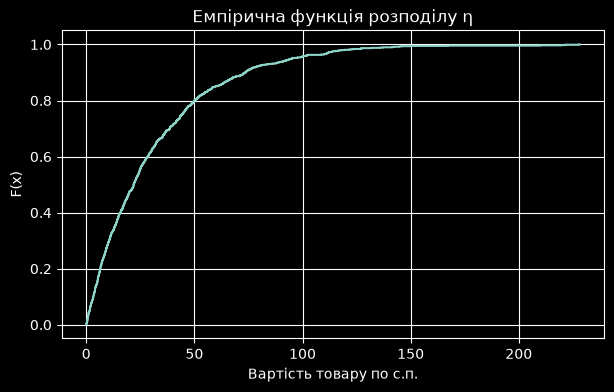

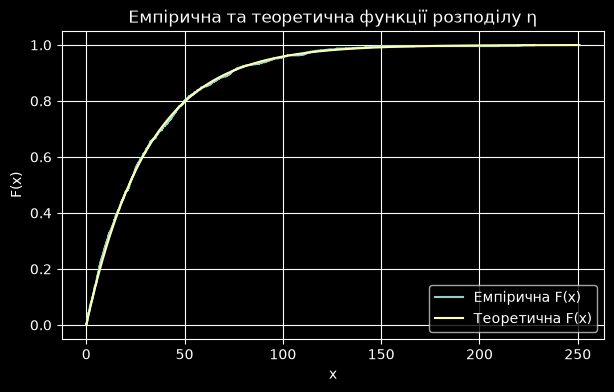

In [9]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# 1. Підготовка даних та розміру вибірки
eta = data['special_proposition'].to_numpy(dtype=float)
n = len(eta)

mu_eta = eta.mean()
s_eta = eta.std(ddof=1)

print(f'Середня вартість товару по с.п. μ̂ = {mu_eta:.6f}')
print(f'Вибіркове стандартне відхилення s = {s_eta:.6f}')

# 2. Обчислення довірчих інтервалів
for confidence in [0.95, 0.99]:
    alpha = 1 - confidence
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margin = t_crit * s_eta / np.sqrt(n)
    print(f'{int(confidence*100)}% ДІ: ({mu_eta - margin:.6f}; {mu_eta + margin:.6f})')

# 3. Емпіричний розподіл та оцінка параметра
eta_sorted = np.sort(eta)
ecdf_eta = np.arange(1, n + 1) / n

lambda_k_hat = 1 / mu_eta
print(f'Оцінка параметра λk = {lambda_k_hat:.6f}')

# 4. Гістограма
plt.figure(figsize=(7, 4))
plt.hist(eta, bins='auto', edgecolor='black')
plt.xlabel('Вартість товару по с.п.')
plt.ylabel('Кількість')
plt.title('Гістограма вартості товарів по с.п.')
plt.grid(True)
plt.show()

# 5. Емпірична функція розподілу
plt.figure(figsize=(7, 4))
plt.step(eta_sorted, ecdf_eta, where='post')
plt.xlabel('Вартість товару по с.п.')
plt.ylabel('F(x)')
plt.title('Емпірична функція розподілу η')
plt.grid(True)
plt.show()

# 6. Порівняння з теоретичною функцією розподілу
xx = np.linspace(0, eta.max() * 1.1, 300)
F_eta = 1 - np.exp(-lambda_k_hat * xx)

plt.figure(figsize=(7, 4))
plt.step(eta_sorted, ecdf_eta, where='post', label='Емпірична F(x)')
plt.plot(xx, F_eta, label='Теоретична F(x)')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Емпірична та теоретична функції розподілу η')
plt.legend()
plt.grid(True)
plt.show()


# 3. Інші товари
Тут нас цікавлять інші товари (без с.п.) та розподіл їх вартостей.
Тут $\xi_i$=$total - special\_proposition$

### Задачі:
1. Оцініть середню вартість товару без с.п. $\mu$
2. Побудуйте середньої вартості товару без с.п. $\mu$ довірчі інтервали із рівнями 95% та 99%

Припустимо, що вартість товарів без с.п. ($\xi_i$) має розподіл $Exp(\lambda)$, $\lambda$>0  
Увага! Тут припускаємо, що $\lambda$ тут і в пункті 2 - один і той же параметр, тобто  
($\eta_i$) має розподіл $Exp(\lambda k)$,  
($\xi_i$) має розподіл $Exp(\lambda)$,  
 k>0, $\lambda$>0  
 
### Задачі:
1. Побудуйте гістограму та еміричну функцію розподілу для ціни товарів інших товарів
2. Оцініть параметр $\lambda$ розподілу. Чи буде оцінка незміщеною? Консистентною?
3. Побудуйте теоретичну функцію розподілу, в який підставите оцінку $\lambda$

### Задача із:
1. (*) (+1) Запропонуйте оцінку для параметра $k$. Тут можна використати знання про розподіли цін товарів з та без с.п.
2. (*) (+5) за доведення консистентності, (+5) чи оцінка зміщена?

1. Оцінка середньої вартості товару без с.п. μ̂ = 99.166547
   Вибіркове стандартне відхилення s_ξ = 97.673519

2. Довірчі інтервали для μ:
    95% ДІ: (93.105447; 105.227646)
    99% ДІ: (91.195334; 107.137760)


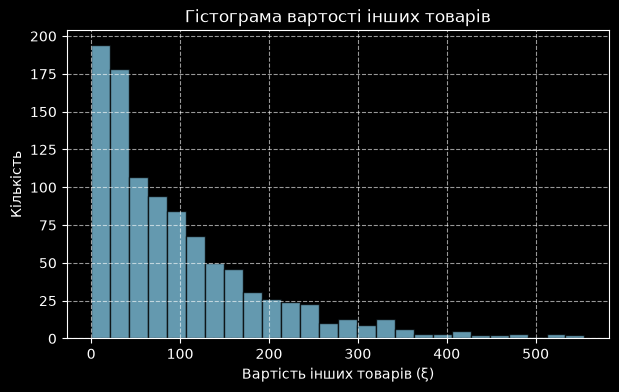

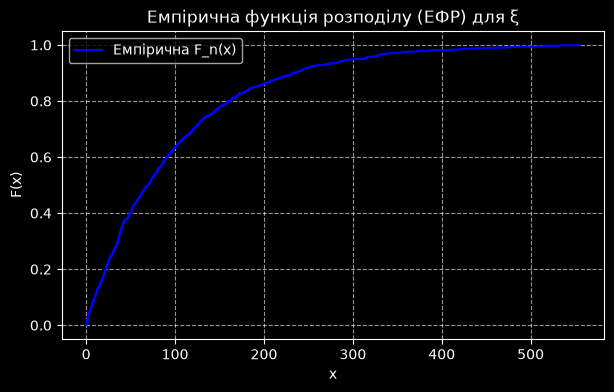

2. Оцінка параметра λ̂ = 1 / μ̂ = 0.010084
   Властивості оцінки:
     Консистентність: ТАК (за Законом великих чисел та теоремою про неперервне відображення).
     Незміщеність: НІ (на скінченній вибірці оцінка є зміщеною, але асимптотично незміщена).


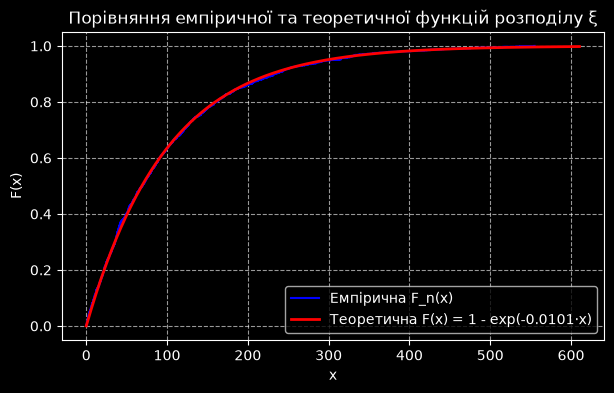

In [10]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

if 'other' not in data.columns:
    data['other'] = data['total'] - data['special_proposition']

xi = data['other'].to_numpy(dtype=float)
n = len(xi)

mu_xi = xi.mean()
s_xi = xi.std(ddof=1)

print(f"1. Оцінка середньої вартості товару без с.п. μ̂ = {mu_xi:.6f}")
print(f"   Вибіркове стандартне відхилення s_ξ = {s_xi:.6f}\n")

print("2. Довірчі інтервали для μ:")
for confidence in [0.95, 0.99]:
    alpha = 1 - confidence
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    margin = t_crit * s_xi / np.sqrt(n)
    print(f"    {int(confidence*100)}% ДІ: ({mu_xi - margin:.6f}; {mu_xi + margin:.6f})")

xi_sorted = np.sort(xi)
ecdf_xi = np.arange(1, n + 1) / n

# 1. Гістограма
plt.figure(figsize=(7, 4))
plt.hist(xi, bins='auto', edgecolor='black', alpha=0.75, color='skyblue')
plt.xlabel('Вартість інших товарів (ξ)')
plt.ylabel('Кількість')
plt.title('Гістограма вартості інших товарів')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Емпірична функція розподілу
plt.figure(figsize=(7, 4))
plt.step(xi_sorted, ecdf_xi, where='post', color='blue', label='Емпірична F_n(x)')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Емпірична функція розподілу (ЕФР) для ξ')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 3. Оцінка параметра λ
lambda_hat = 1 / mu_xi
print(f"2. Оцінка параметра λ̂ = 1 / μ̂ = {lambda_hat:.6f}")
print("   Властивості оцінки:")
print("     Консистентність: ТАК (за Законом великих чисел та теоремою про неперервне відображення).")
print("     Незміщеність: НІ (на скінченній вибірці оцінка є зміщеною, але асимптотично незміщена).")

# 4. Побудова теоретичної функції розподілу Exp(λ̂)
xx = np.linspace(0, xi.max() * 1.1, 300)
F_xi_theory = 1 - np.exp(-lambda_hat * xx)

plt.figure(figsize=(7, 4))
plt.step(xi_sorted, ecdf_xi, where='post', color='blue', label='Емпірична F_n(x)')
plt.plot(xx, F_xi_theory, color='red', linewidth=2, label=f'Теоретична F(x) = 1 - exp(-{lambda_hat:.4f}·x)')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.title('Порівняння емпіричної та теоретичної функцій розподілу ξ')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# 4. Доля с.п. у замовлені

В цьому розділі нас цікавить частка товарів з с.п. у замовленні. Тобто, величини $\frac{\eta_i}{\xi_i+\eta_i}$. Можливо, вони якось пов'язані із поверненнями.
Чи залежать поверення від частки акційних товарів? Доведіть! (побудуйте аналітику!)

У припущенні, що ($\eta_i$) має розподіл $Exp(\lambda k)$,  та ($\xi_i$) має розподіл $Exp(\lambda)$

## Задачі по варіантам:

1. Чи можливо лише по вибірці з $\frac{\eta_i}{\xi_i+\eta_i}$ оцінити параметри $\lambda$ та $k$?
2. Чи можливо лише по вибірці з $\frac{\xi_i}{\xi_i+\eta_i}$ оцінити параметри $\lambda$ та $k$?
3. Чи можливо лише по вибірці з $\frac{\xi_i}{\eta_i}$ оцінити параметри $\lambda$ та $k$?
4. Чи можливо лише по вибірці з $\xi_i + \eta_i$ оцінити параметри $\lambda$ та $k$?
5. Чи можливо лише по вибірці з $\xi_i - \eta_i$ оцінити параметри $\lambda$ та $k$?
6. Чи можливо лише по вибірці з $1/  (\xi_i + \eta_i)$ оцінити параметри $\lambda$ та $k$?

Вибіркове середнє Ū = 0.682921
1. Оцінка параметра k̂ (через вибірку U) = 2.153785
2. Оцінка параметра λ: НЕМОЖЛИВА лише по цій вибірці, оскільки параметр λ 
   скорочується у відношенні ξ / (ξ + η) і не впливає на розподіл U.

Середня частка с.п. при поверненні: 0.0481
Середня частка с.п. без повернення: 0.4207
p-value для T-тесту порівняння часток: 0.000000
Висновок: Є статистично значуща залежність між часткою с.п. та поверненням.


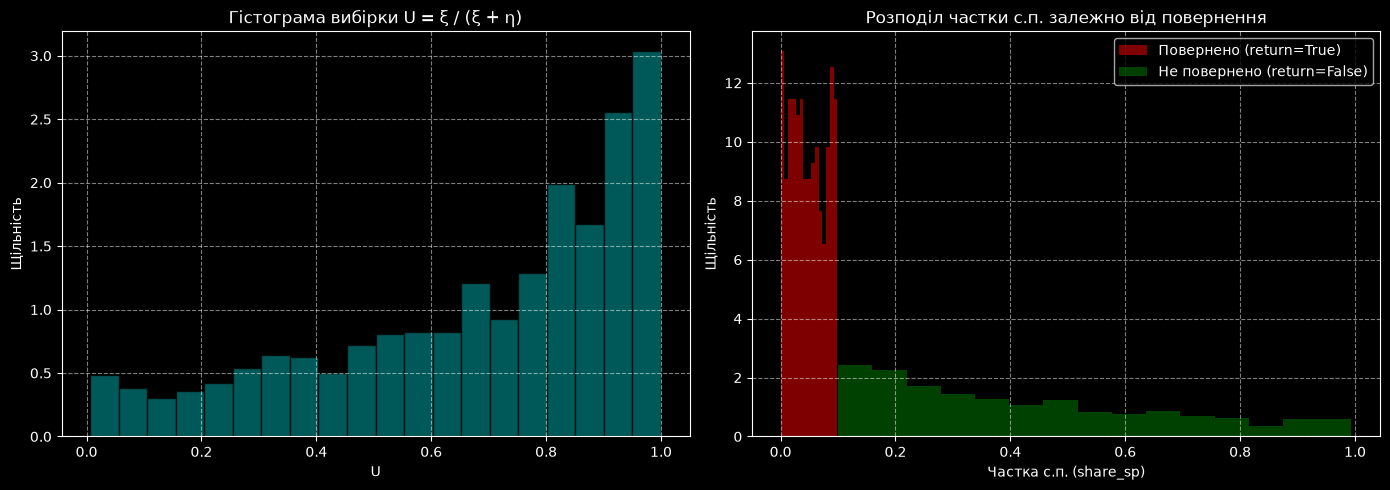

In [11]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

xi = data['other'].to_numpy(dtype=float)
eta = data['special_proposition'].to_numpy(dtype=float)

U = xi / (xi + eta)
n = len(U)

mean_U = U.mean()

# Метод моментів для k: E[U] = k / (k + 1)  =>  k = E[U] / (1 - E[U])
k_hat_v2 = mean_U / (1 - mean_U)

print(f"Вибіркове середнє Ū = {mean_U:.6f}")
print(f"1. Оцінка параметра k̂ (через вибірку U) = {k_hat_v2:.6f}")
print("2. Оцінка параметра λ: НЕМОЖЛИВА лише по цій вибірці, оскільки параметр λ ")
print("   скорочується у відношенні ξ / (ξ + η) і не впливає на розподіл U.\n")

# Додаємо частку акційних товарів
if 'share_sp' not in data.columns:
    data['share_sp'] = eta / (xi + eta)

share_returns = data.loc[data['return'] == True, 'share_sp']
share_no_returns = data.loc[data['return'] == False, 'share_sp']

print(f"Середня частка с.п. при поверненні: {share_returns.mean():.4f}")
print(f"Середня частка с.п. без повернення: {share_no_returns.mean():.4f}")

t_stat, p_val = stats.ttest_ind(share_returns, share_no_returns, equal_var=False)
print(f"p-value для T-тесту порівняння часток: {p_val:.6f}")
if p_val < 0.05:
    print("Висновок: Є статистично значуща залежність між часткою с.п. та поверненням.")
else:
    print("Висновок: Немає статистично значущої залежності між часткою с.п. та поверненням.")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гістограма
axes[0].hist(U, bins=20, density=True, edgecolor='black', alpha=0.7, color='teal')
axes[0].set_title('Гістограма вибірки U = ξ / (ξ + η)')
axes[0].set_xlabel('U')
axes[0].set_ylabel('Щільність')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Порівняльний графік
axes[1].hist(share_returns, bins=15, alpha=0.5, label='Повернено (return=True)', density=True, color='red')
axes[1].hist(share_no_returns, bins=15, alpha=0.5, label='Не повернено (return=False)', density=True, color='green')
axes[1].set_title('Розподіл частки с.п. залежно від повернення')
axes[1].set_xlabel('Частка с.п. (share_sp)')
axes[1].set_ylabel('Щільність')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()